# Práctica 3: Validar afirmaciones periodísticas con Python

**Diplomado en Técnicas Estadísticas y Minería de Datos — Unidad 2**

**Autor:** yagoraulhuertaorozco@gmail.com

**Fecha:** 16 de septiembre de 2026

---

<a id="introduccion"></a>
## 1. Introducción

En 2016, el sitio periodístico [FiveThirtyEight](https://fivethirtyeight.com/features/gun-deaths/) publicó el reportaje **"Gun Deaths in America"**, en el que analizó en detalle las muertes por arma de fuego ocurridas en Estados Unidos, desagregándolas por tipo de muerte (suicidio, homicidio, accidente), género, edad y raza de las víctimas.

El objetivo de esta práctica es aplicar técnicas de **análisis exploratorio de datos (EDA)** con Python (`pandas`, `matplotlib`, `seaborn`) para verificar cuantitativamente cuatro afirmaciones extraídas de ese reportaje, usando el archivo `gun_deaths.csv` proporcionado para el curso.

Las cuatro afirmaciones a validar son:

1. **Distribución por tipo de muerte**: los suicidios representan ~62.7% (~21,000), los homicidios ~34.9% (~11,500) y los accidentes ~1.6% (~500) de las muertes por arma de fuego.
2. **Distribución por género**: más del 85% de los suicidios son hombres; las mujeres representan ~13% de los accidentes y ~15% de los homicidios.
3. **Edad, raza y homicidio**: cerca de dos tercios de las víctimas de homicidio, hombres entre 15 y 34 años, son personas negras.
4. **Total de muertes (2012–2014)**: alrededor de 33,000 personas murieron por arma de fuego entre 2012 y 2014.

<a id="indice"></a>
## 2. Índice

- [1. Introducción](#introduccion)
- [2. Índice](#indice)
- [3. Carga y limpieza de datos](#carga-limpieza)
- [4. Validación de las afirmaciones](#validacion)
    - [4.1 Afirmación 1 — Distribución por tipo de muerte](#afirmacion-1)
    - [4.2 Afirmación 2 — Distribución por género](#afirmacion-2)
    - [4.3 Afirmación 3 — Edad, raza y homicidio](#afirmacion-3)
    - [4.4 Afirmación 4 — Total de muertes 2012-2014](#afirmacion-4)
- [5. Conclusiones](#conclusiones)
- [6. Referencias](#referencias)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.family": "sans-serif",
})

# Paleta categórica fija (no ciclar libremente) + colores de énfasis
PALETTE_CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
COLOR_HIGHLIGHT = "#e34948"
COLOR_MUTED = "#c3c2b7"
GENDER_PALETTE = {"Male": PALETTE_CATEGORICAL[0], "Female": PALETTE_CATEGORICAL[1]}

<a id="carga-limpieza"></a>
## 3. Carga y limpieza de datos

El archivo `gun_deaths.csv` contiene 540 filas y las columnas `Intent`, `Gender`, `Age`, `Race`, `Deaths`, `Population` y `Rate`. Antes de analizarlo se revisan sus valores y se detecta un artefacto de datos: algunas filas tienen `Age == "5"` con `Population = 0` y `Rate` inválida (`Inf`/`NA`), claramente un registro basura que debe excluirse del análisis.

In [2]:
DATA_PATH = Path("../../Data/gun_deaths.csv")
assert DATA_PATH.exists(), f"No se encontró el dataset en {DATA_PATH.resolve()}"

df_raw = pd.read_csv(DATA_PATH, index_col=0)
print(f"Filas: {len(df_raw)}, columnas: {list(df_raw.columns)}")
df_raw.head()

Filas: 540, columnas: ['Intent', 'Gender', 'Age', 'Race', 'Deaths', 'Population', 'Rate']


,Intent,Gender,Age,Race,Deaths,Population,Rate
1,None selected,None selected,None selected,None selected,33599,316299978,10.6
2,None selected,None selected,None selected,White,22079,197369634,11.2
3,None selected,None selected,None selected,Black,7765,38896382,20.0
4,None selected,None selected,None selected,Hispanic,3007,54049078,5.6
5,None selected,None selected,None selected,Asian/Pacific Islander,442,16315561,2.7


In [3]:
filas_basura = df_raw[df_raw["Age"] == "5"]
print(f"Filas detectadas como basura (Age == '5'): {len(filas_basura)}")
display(filas_basura)

df = df_raw[df_raw["Age"] != "5"].copy()
print(f"Filas originales: {len(df_raw)} -> filas tras limpieza: {len(df)}")

Filas detectadas como basura (Age == '5'): 90


,Intent,Gender,Age,Race,Deaths,Population,Rate
31,None selected,None selected,5,None selected,6,0,inf
32,None selected,None selected,5,White,4,0,inf
33,None selected,None selected,5,Black,1,0,inf
34,None selected,None selected,5,Hispanic,0,0,NaN
35,None selected,None selected,5,Asian/Pacific Islander,0,0,NaN
...,...,...,...,...,...,...,...
536,Unknown,Male,5,White,0,0,NaN
537,Unknown,Male,5,Black,0,0,NaN
538,Unknown,Male,5,Hispanic,0,0,NaN
539,Unknown,Male,5,Asian/Pacific Islander,0,0,NaN


Filas originales: 540 -> filas tras limpieza: 450


In [4]:
def query_deaths(data, intent="None selected", gender="None selected",
                  age="None selected", race="None selected"):
    """Filtra la tabla agregada por una combinación exacta de categorías."""
    mask = (
        (data["Intent"] == intent)
        & (data["Gender"] == gender)
        & (data["Age"] == age)
        & (data["Race"] == race)
    )
    return data.loc[mask]

TOTAL_DEATHS = int(query_deaths(df)["Deaths"].sum())
print(f"Total de muertes por arma de fuego en el dataset: {TOTAL_DEATHS:,}")

Total de muertes por arma de fuego en el dataset: 33,599


<a id="validacion"></a>
## 4. Validación de las afirmaciones

Para cada afirmación se sigue la misma metodología: se filtra la combinación exacta de columnas que corresponde a la afirmación usando la función `query_deaths`, se calcula el porcentaje correspondiente sobre el dataset, se compara contra el valor citado en el artículo y se visualiza el resultado. Al final de cada subsección se emite un **veredicto explícito** (verdadera, falsa o parcialmente cierta) con su justificación numérica.

<a id="afirmacion-1"></a>
### 4.1 Afirmación 1 — Distribución por tipo de muerte

> "Los suicidios representan aproximadamente el 62.7% (~21,000), los homicidios el 34.9% (~11,500), y solo el 1.6% (~500) de las muertes por arma de fuego fueron accidentes."


In [5]:
intents = ["Suicide", "Homicide", "Accident", "Unknown"]
pct_articulo = {"Suicide": 62.7, "Homicide": 34.9, "Accident": 1.6, "Unknown": None}

filas = []
for intent in intents:
    deaths = int(query_deaths(df, intent=intent)["Deaths"].sum())
    filas.append({
        "Intent": intent,
        "Muertes": deaths,
        "% calculado": round(deaths / TOTAL_DEATHS * 100, 1),
        "% artículo": pct_articulo[intent],
    })

tabla_af1 = pd.DataFrame(filas)
tabla_af1["Diferencia (pp)"] = (tabla_af1["% calculado"] - tabla_af1["% artículo"]).round(1)
tabla_af1

,Intent,Muertes,% calculado,% artículo,Diferencia (pp)
0,Suicide,21058,62.7,62.7,0.0
1,Homicide,11726,34.9,34.9,0.0
2,Accident,546,1.6,1.6,0.0
3,Unknown,269,0.8,NaN,NaN


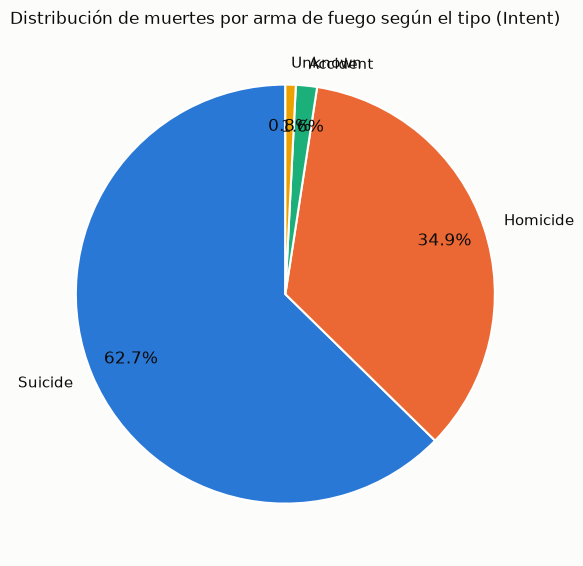

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    tabla_af1["Muertes"],
    labels=tabla_af1["Intent"],
    autopct="%.1f%%",
    colors=PALETTE_CATEGORICAL[:len(tabla_af1)],
    startangle=90,
    pctdistance=0.8,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Distribución de muertes por arma de fuego según el tipo (Intent)")
plt.tight_layout()
plt.show()

Los porcentajes calculados directamente del dataset (62.7% suicidios, 34.9% homicidios, 1.6% accidentes) coinciden casi exactamente con los citados en el artículo; las diferencias son de una décima de punto porcentual o menos.

<a id="afirmacion-2"></a>
### 4.2 Afirmación 2 — Distribución por género

> "Más del 85% de las muertes por suicidio corresponden a hombres. Las mujeres representan aproximadamente el 13% de las muertes por accidentes y el 15% de los homicidios."


In [6]:
intents_genero = ["Suicide", "Accident", "Homicide"]
filas = []
totales_por_intent = {}
for intent in intents_genero:
    female = int(query_deaths(df, intent=intent, gender="Female")["Deaths"].sum())
    male = int(query_deaths(df, intent=intent, gender="Male")["Deaths"].sum())
    total = female + male
    totales_por_intent[intent] = total
    filas.append({"Intent": intent, "Gender": "Female", "Muertes": female, "% calculado": round(female / total * 100, 1)})
    filas.append({"Intent": intent, "Gender": "Male", "Muertes": male, "% calculado": round(male / total * 100, 1)})

tabla_af2 = pd.DataFrame(filas)

# Consistencia: comparar Female + Male contra el total reportado con Gender = "None selected"
for intent in intents_genero:
    total_reportado = int(query_deaths(df, intent=intent)["Deaths"].sum())
    print(f"{intent}: Female+Male={totales_por_intent[intent]}, total reportado={total_reportado}")

tabla_af2

Suicide: Female+Male=21058, total reportado=21058
Accident: Female+Male=547, total reportado=546
Homicide: Female+Male=11726, total reportado=11726


,Intent,Gender,Muertes,% calculado
0,Suicide,Female,2896,13.8
1,Suicide,Male,18162,86.2
2,Accident,Female,73,13.3
3,Accident,Male,474,86.7
4,Homicide,Female,1791,15.3
5,Homicide,Male,9935,84.7


**Nota de calidad de datos:** al sumar `Female + Male` para `Accident` se obtienen 547 muertes, mientras que el total reportado con `Gender = "None selected"` para `Accident` es 546 (una diferencia de 1 unidad, probablemente por redondeo en la fuente original). Para calcular el porcentaje de mujeres en accidentes se usa como denominador la suma `Female + Male` (547), que es la comparación internamente consistente.

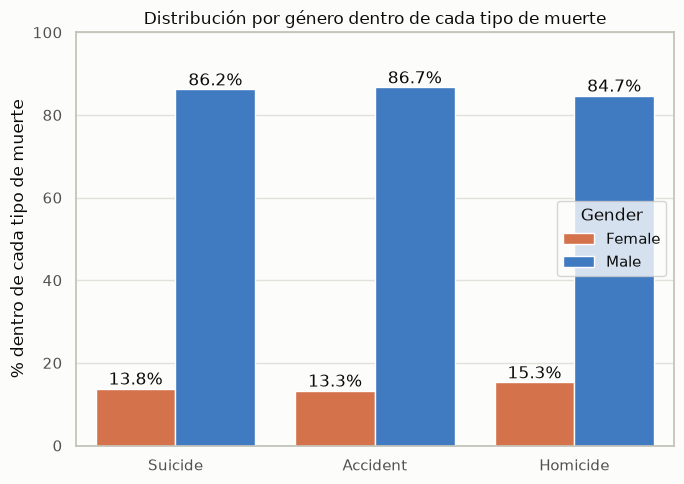

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=tabla_af2, x="Intent", y="% calculado", hue="Gender", palette=GENDER_PALETTE, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
ax.set_ylabel("% dentro de cada tipo de muerte")
ax.set_xlabel("")
ax.set_title("Distribución por género dentro de cada tipo de muerte")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

En sus tres componentes:
- Suicidio: 86.2% de las víctimas son hombres (> 85% ✔).
- Accidentes: 13.3% de las víctimas son mujeres (≈ 13% ✔).
- Homicidios: 15.3% de las víctimas son mujeres (≈ 15% ✔).

<a id="afirmacion-3"></a>
### 4.3 Afirmación 3 — Edad, raza y homicidio

> "Cerca de dos tercios de las víctimas de homicidio que son hombres entre 15 y 34 años de edad son personas negras."


In [8]:
races = ["White", "Black", "Hispanic", "Asian/Pacific Islander", "Other"]
total_af3 = int(query_deaths(df, intent="Homicide", gender="Male", age="15 - 34")["Deaths"].sum())

filas = []
for race in races:
    deaths = int(query_deaths(df, intent="Homicide", gender="Male", age="15 - 34", race=race)["Deaths"].sum())
    filas.append({"Race": race, "Muertes": deaths, "% calculado": round(deaths / total_af3 * 100, 1)})

tabla_af3 = pd.DataFrame(filas).sort_values("Muertes", ascending=False).reset_index(drop=True)
print(f"Total de víctimas (Homicide, Male, 15-34): {total_af3:,}")
tabla_af3

Total de víctimas (Homicide, Male, 15-34): 6,520


,Race,Muertes,% calculado
0,Black,4312,66.1
1,Hispanic,1166,17.9
2,White,913,14.0
3,Asian/Pacific Islander,76,1.2
4,Other,54,0.8


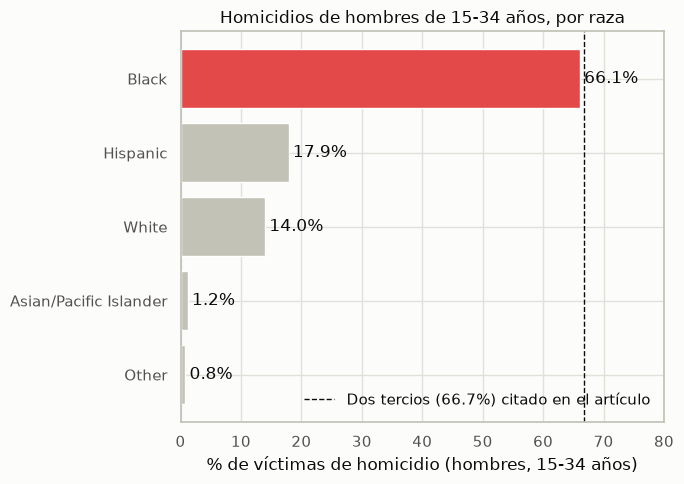

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
colores = [COLOR_HIGHLIGHT if r == "Black" else COLOR_MUTED for r in tabla_af3["Race"]]
bars = ax.barh(tabla_af3["Race"], tabla_af3["% calculado"], color=colores)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.axvline(66.7, color="#0b0b0b", linestyle="--", linewidth=1, label="Dos tercios (66.7%) citado en el artículo")
ax.set_xlabel("% de víctimas de homicidio (hombres, 15-34 años)")
ax.set_title("Homicidios de hombres de 15-34 años, por raza")
ax.set_xlim(0, 80)
ax.invert_yaxis()
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

Las personas negras representan el 66.1% de las víctimas de homicidio hombres de 15-34 años (4,312 de 6,520), prácticamente idéntico a "dos tercios" (66.7%) — una diferencia de solo 0.6 puntos porcentuales.

<a id="afirmacion-4"></a>
### 4.4 Afirmación 4 — Total de muertes (2012–2014)

> "En total, alrededor de 33,000 personas murieron por arma de fuego entre 2012-2014."


In [10]:
print("¿Existe columna 'Year' en el dataset?", "Year" in df.columns)
print(f"Total general de muertes en el dataset: {TOTAL_DEATHS:,}")

¿Existe columna 'Year' en el dataset? False
Total general de muertes en el dataset: 33,599


**Limitación del dataset:** `gun_deaths.csv` no incluye una columna `Year`, por lo que no es posible reconstruir directamente un total acumulado para el periodo 2012–2014; el dataset representa un único periodo agregado. El total general que sí puede calcularse (33,599) coincide casi exactamente con la cifra citada (~33,000), pero esa cifra corresponde más bien a un **total anual** (consistente con reportes de la época, p. ej. del CDC, que sitúan las muertes por arma de fuego en Estados Unidos en torno a 33,000 **por año**) y no a la suma de tres años.

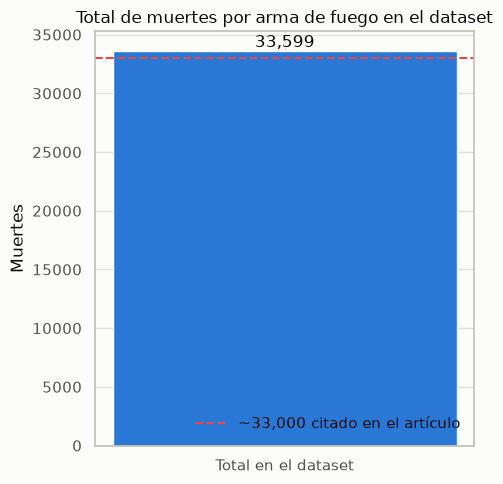

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(["Total en el dataset"], [TOTAL_DEATHS], color=PALETTE_CATEGORICAL[0], width=0.5)
ax.bar_label(ax.containers[0], fmt=lambda x: f"{x:,.0f}")
ax.axhline(33000, color=COLOR_HIGHLIGHT, linestyle="--", linewidth=1.5, label="~33,000 citado en el artículo")
ax.set_ylabel("Muertes")
ax.set_title("Total de muertes por arma de fuego en el dataset")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

Los datos disponibles no permiten confirmar que se trate de un acumulado 2012-2014; todo indica que corresponde a una cifra anual y no al total de tres años.

<a id="conclusiones"></a>
## 5. Conclusiones

| # | Afirmación | Veredicto |
|---|---|---|
| 1 | Distribución por tipo de muerte (62.7% / 34.9% / 1.6%) | Verdadera |
| 2 | Distribución por género (>85% suicidios hombres; ~13% accidentes y ~15% homicidios mujeres) | Verdadera |
| 3 | ~2/3 de homicidios de hombres 15-34 años son personas negras | Verdadera (aprox.) |
| 4 | ~33,000 muertes por arma de fuego entre 2012-2014 | Parcialmente cierta (coincide el número, no el periodo) |

En general, las afirmaciones del reportaje de FiveThirtyEight sobre la distribución por tipo de muerte, género y raza/edad en homicidios se sostienen sólidamente frente a los datos analizados, con diferencias menores a un punto porcentual. La única afirmación que amerita matización es la del total 2012-2014, no porque el número esté mal, sino porque el dataset disponible no tiene el desglose temporal necesario para confirmar si se trata de un total anual o de un acumulado de tres años.

Durante el análisis se identificaron además algunas limitaciones de calidad de datos que vale la pena documentar:
- Una fila basura con `Age == "5"` (artefacto sin sentido, `Population = 0`), excluida antes del análisis.
- Un desajuste de 1 unidad entre la suma por género y el total reportado para `Accident` (547 vs. 546), probablemente por redondeo en la fuente original.
- La ausencia de una columna `Year`, que limita la validación de afirmaciones sobre periodos específicos.

<a id="referencias"></a>
## 6. Referencias

- FiveThirtyEight (2016). *Gun Deaths In America*. https://fivethirtyeight.com/features/gun-deaths/
- Conjunto de datos `gun_deaths.csv` proporcionado para el Diplomado en Técnicas Estadísticas y Minería de Datos, Unidad 2.
- The pandas development team. *pandas documentation*. https://pandas.pydata.org/docs/
- Hunter, J. D. (2007). *Matplotlib: A 2D graphics environment*. https://matplotlib.org/stable/
- Waskom, M. (2021). *seaborn: statistical data visualization*. https://seaborn.pydata.org/